# Amazon Music Clustering
We will group similar music records using simple machine learning steps.
This notebook is written for beginners and uses easy Python code.


In [9]:
# Show a simple welcome message for the project.
print('Welcome to the Amazon Music Clustering project.')
print('We will explore the data step by step in a beginner-friendly way.')


Welcome to the Amazon Music Clustering project.
We will explore the data step by step in a beginner-friendly way.


# Import Libraries
We import the basic libraries needed for data science and clustering.
These tools help us read data, make charts, and build models.


In [10]:
# Import only the libraries we need.
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)

# File path for the dataset.
data_path = Path('single_genre_artists.csv')


# Load Dataset
We read the CSV file into a pandas DataFrame.
If the file is missing, Python will show a clear error.


In [11]:
# Load the dataset.
if not data_path.exists():
    raise FileNotFoundError('single_genre_artists.csv was not found in this folder.')

df = pd.read_csv(data_path)
print('Dataset loaded successfully')
print('Shape:', df.shape)


Dataset loaded successfully
Shape: (95837, 23)


# Display First 5 Rows
The first rows help us see what the dataset looks like.
This is a quick check before we clean or analyze anything.


In [12]:
# Show the first 5 rows.
display(df.head())


,id_songs,name_song,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists
0,0IA0Hju8CAgYfV1hwhidBH,La Java,0,161427,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.563,0.184,4,...,0.993,0.000016,0.325,0.654,133.088,3,5078.0,['vintage chanson'],Mistinguett,22
1,1b8HZQCqcqwbzlA1jRTp6E,En Douce,0,223440,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.427,0.180,10,...,0.989,0.000000,0.128,0.431,78.459,3,5078.0,['vintage chanson'],Mistinguett,22
2,5d5gQxHwYovxR5pqETOIAa,J'en Ai Marre,0,208267,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.511,0.206,0,...,0.995,0.000000,0.418,0.481,70.443,4,5078.0,['vintage chanson'],Mistinguett,22
3,1EO65UEEPfy7CR0NK2sDxy,Ils n'ont pas ca,0,161933,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.676,0.467,9,...,0.991,0.000000,0.219,0.726,129.775,4,5078.0,['vintage chanson'],Mistinguett,22
4,6a58gXSgqbIsXUhVZ6ZJqe,La belote,0,167973,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.650,0.298,9,...,0.991,0.000000,0.373,0.844,75.950,4,5078.0,['vintage chanson'],Mistinguett,22


# Display Last 5 Rows
The last rows help us check the end of the dataset.
It also helps us confirm the data was read correctly.


In [13]:
# Show the last 5 rows.
display(df.tail())


,id_songs,name_song,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists
95832,44r4zta6P9flkhKaVnbsvG,Freaks,70,174800,0,14Y3trk7LaslSFTk1G35rx,2019-02-25,0.674,0.5680,1,...,0.116,0.000,0.1650,0.640,166.107,4,16057.0,['alt z'],Jordan Clarke,56
95833,0MmaEacabpK8Yp3Mdeo5uY,下雨天,50,265846,0,5VGgFE9nPgMfEnYiPT5J2B,2020-02-25,0.528,0.6730,4,...,0.143,0.000,0.0989,0.297,130.066,4,929.0,['chinese viral pop'],芝麻,36
95834,1dKxf4Ht2SsKLyXfSDJAgy,The Cutest Puppy,67,82500,0,7vgGpuiXdNlCmc994PlMlz,2020-10-30,0.609,0.0172,8,...,0.996,0.973,0.1080,0.890,68.619,4,23.0,['instrumental lullaby'],Laureen Conrad,52
95835,0SjsIzJkZfDU7wlcdklEFR,John Brown's Song,66,185250,0,4MxqhahGRT4BPz1PilXGeu,2020-03-20,0.562,0.0331,1,...,0.996,0.961,0.1110,0.386,63.696,3,91.0,['instrumental lullaby'],Gregory Oberle,55
95836,5rgu12WBIHQtvej2MdHSH0,云与海,50,258267,0,1QLBXKM5GCpyQQSVMNZqrZ,2020-09-26,0.560,0.5180,0,...,0.785,0.000,0.0648,0.211,131.896,4,896.0,['chinese viral pop'],阿YueYue,38


# Dataset Shape
Shape tells us the number of rows and columns.
It is one of the simplest checks for any dataset.


In [14]:
# Print rows and columns.
print('Rows:', df.shape[0])
print('Columns:', df.shape[1])


Rows: 95837
Columns: 23


# Dataset Information
Information tells us the data type of each column and missing counts.
This helps us understand the dataset before cleaning.


In [15]:
# Show column types and non-null counts.
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 95837 entries, 0 to 95836
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_songs            95837 non-null  str    
 1   name_song           95837 non-null  str    
 2   popularity_songs    95837 non-null  int64  
 3   duration_ms         95837 non-null  int64  
 4   explicit            95837 non-null  int64  
 5   id_artists          95837 non-null  str    
 6   release_date        95837 non-null  str    
 7   danceability        95837 non-null  float64
 8   energy              95837 non-null  float64
 9   key                 95837 non-null  int64  
 10  loudness            95837 non-null  float64
 11  mode                95837 non-null  int64  
 12  speechiness         95837 non-null  float64
 13  acousticness        95837 non-null  float64
 14  instrumentalness    95837 non-null  float64
 15  liveness            95837 non-null  float64
 16  valence        

# Statistical Summary
This gives basic summary values for the dataset.
It helps us understand numbers and counts in simple form.


In [16]:
# Show summary statistics.
display(df.describe(include='all'))


,id_songs,name_song,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists
count,95837,95837,95837.000000,9.583700e+04,95837.000000,95837,95837,95837.000000,95837.000000,95837.000000,...,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,9.583700e+04,95837,95837,95837.000000
unique,95837,85427,NaN,NaN,NaN,18009,10436,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3153,17662,NaN
top,0IA0Hju8CAgYfV1hwhidBH,Bibi Blocksberg Lied,NaN,NaN,NaN,3meJIgRw7YleJrmbpbJK6S,1983,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,['hoerspiel'],Die drei ???,NaN
freq,1,33,NaN,NaN,NaN,3856,754,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8027,3856,NaN
mean,NaN,NaN,26.066394,2.087320e+05,0.029644,NaN,NaN,0.586853,0.541083,5.196782,...,0.458989,0.082145,0.224916,0.574281,117.539870,3.851362,1.979919e+05,NaN,NaN,42.819329
std,NaN,NaN,16.254133,1.177526e+05,0.169604,NaN,NaN,0.155422,0.236304,3.534923,...,0.330416,0.232440,0.185829,0.248126,30.190399,0.544406,7.807520e+05,NaN,NaN,20.897833
min,NaN,NaN,0.000000,6.373000e+03,0.000000,NaN,NaN,0.000000,0.000020,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,NaN,NaN,0.000000
25%,NaN,NaN,13.000000,1.573330e+05,0.000000,NaN,NaN,0.488000,0.365000,2.000000,...,0.133000,0.000000,0.100000,0.378000,94.829000,4.000000,2.563000e+03,NaN,NaN,28.000000
50%,NaN,NaN,26.000000,2.040000e+05,0.000000,NaN,NaN,0.605000,0.542000,5.000000,...,0.453000,0.000004,0.149000,0.589000,116.595000,4.000000,1.595600e+04,NaN,NaN,40.000000
75%,NaN,NaN,37.000000,2.502670e+05,0.000000,NaN,NaN,0.700000,0.727000,8.000000,...,0.759000,0.001300,0.302000,0.780000,135.975000,4.000000,8.495100e+04,NaN,NaN,56.000000


# Column Names
We print the column names to understand the dataset structure.
This helps us decide which columns are useful.


In [17]:
# Show all column names.
print('Column names:')
print(list(df.columns))


Column names:
['id_songs', 'name_song', 'popularity_songs', 'duration_ms', 'explicit', 'id_artists', 'release_date', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'followers', 'genres', 'name_artists', 'popularity_artists']


# Check Missing Values
Missing values can affect our results.
We check them before cleaning the data.


In [18]:
# Count missing values in each column.
missing_values = df.isnull().sum()
display(missing_values.to_frame('Missing Count'))


,Missing Count
id_songs,0
name_song,0
popularity_songs,0
duration_ms,0
explicit,0
id_artists,0
release_date,0
danceability,0
energy,0
key,0


# Check Duplicate Values
Duplicate rows can give repeated information.
We check how many duplicate rows are present.


In [19]:
# Count duplicate rows.
duplicate_count = df.duplicated().sum()
print('Duplicate rows:', duplicate_count)
if duplicate_count > 0:
    display(df[df.duplicated()].head())


Duplicate rows: 0


# Drop Unnecessary Columns
Some columns may not help clustering, like unnamed index columns.
We remove only obvious useless columns.


In [20]:
# Remove unnamed or constant columns.
df_clean = df.copy()
columns_to_drop = []

for column in df_clean.columns:
    column_name = str(column).lower()
    if column_name.startswith('unnamed') or 'index' in column_name:
        columns_to_drop.append(column)
    elif df_clean[column].nunique(dropna=False) <= 1:
        columns_to_drop.append(column)

df_clean = df_clean.drop(columns=columns_to_drop, errors='ignore')
print('Dropped columns:', columns_to_drop)
print('New shape:', df_clean.shape)


Dropped columns: []
New shape: (95837, 23)


# Histograms
Histograms show how values are spread in each numeric column.
They help us see the shape of the data in a simple way.


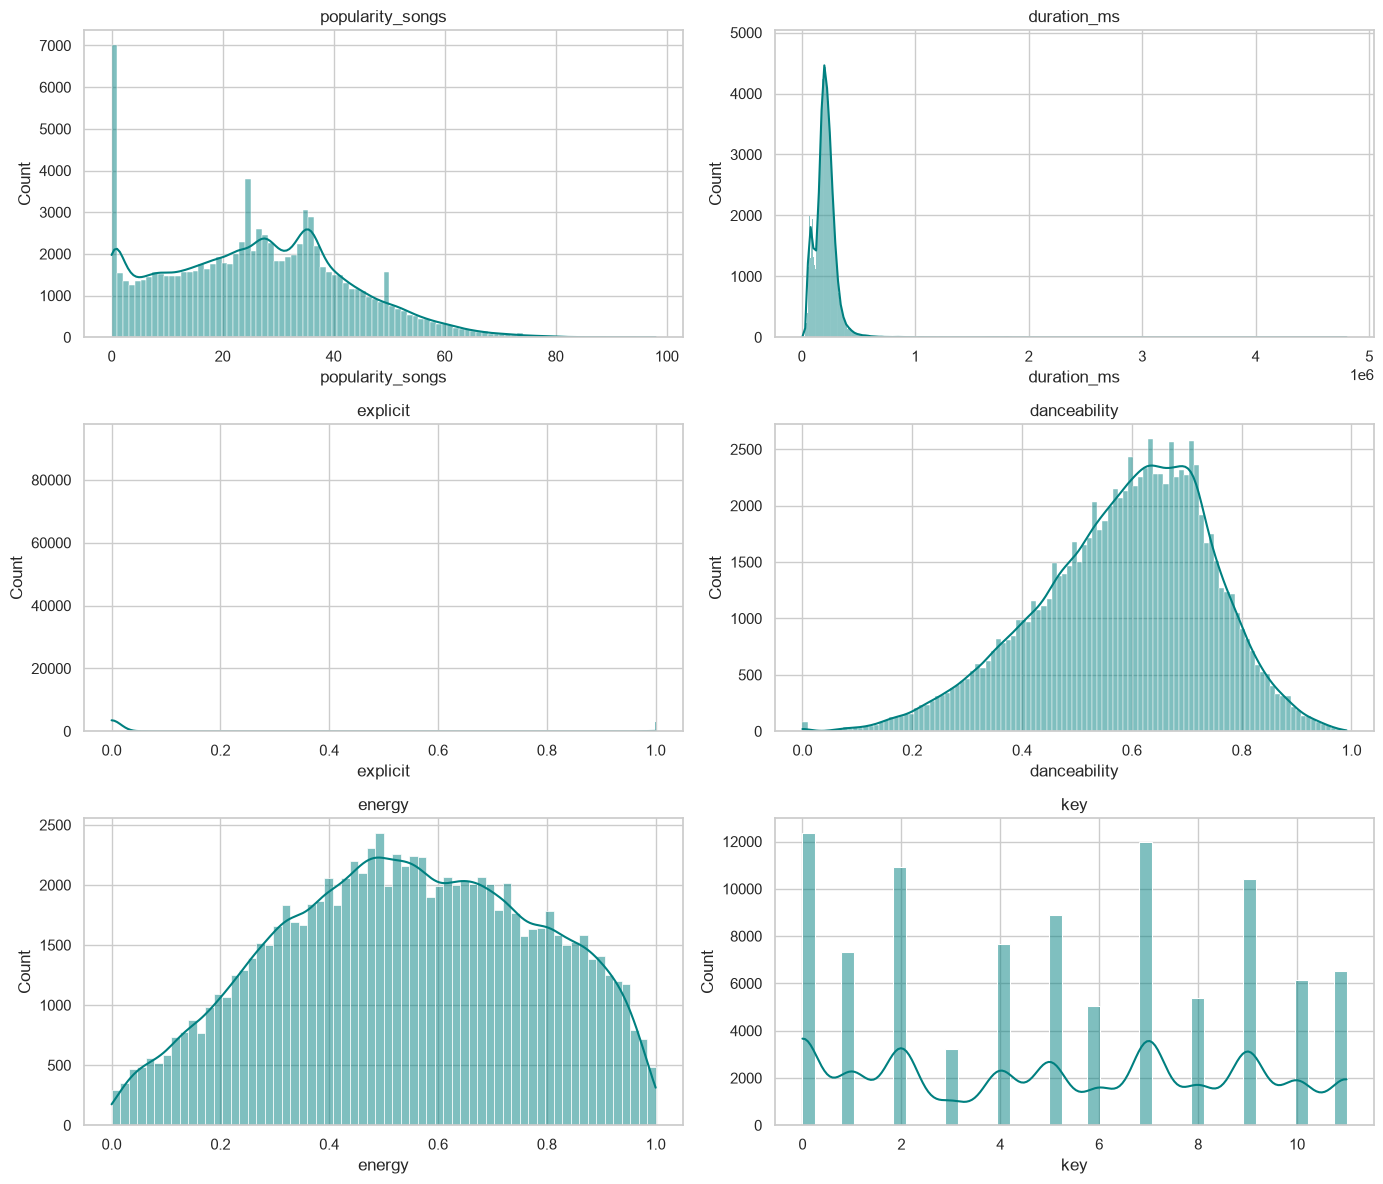

In [21]:
# Plot histograms for numeric columns.
numeric_columns = df_clean.select_dtypes(include=np.number).columns.tolist()
plot_columns = numeric_columns[:6]

if len(plot_columns) == 0:
    print('No numeric columns found for histograms.')
else:
    rows = int(np.ceil(len(plot_columns) / 2))
    fig, axes = plt.subplots(rows, 2, figsize=(14, 4 * rows))
    axes = np.array(axes).reshape(-1)
    for ax, column in zip(axes, plot_columns):
        sns.histplot(df_clean[column], kde=True, ax=ax, color='teal')
        ax.set_title(column)
    for ax in axes[len(plot_columns):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()


# Boxplots
Boxplots help us see spread, median, and outliers.
They are useful before clustering because outliers can affect distances.


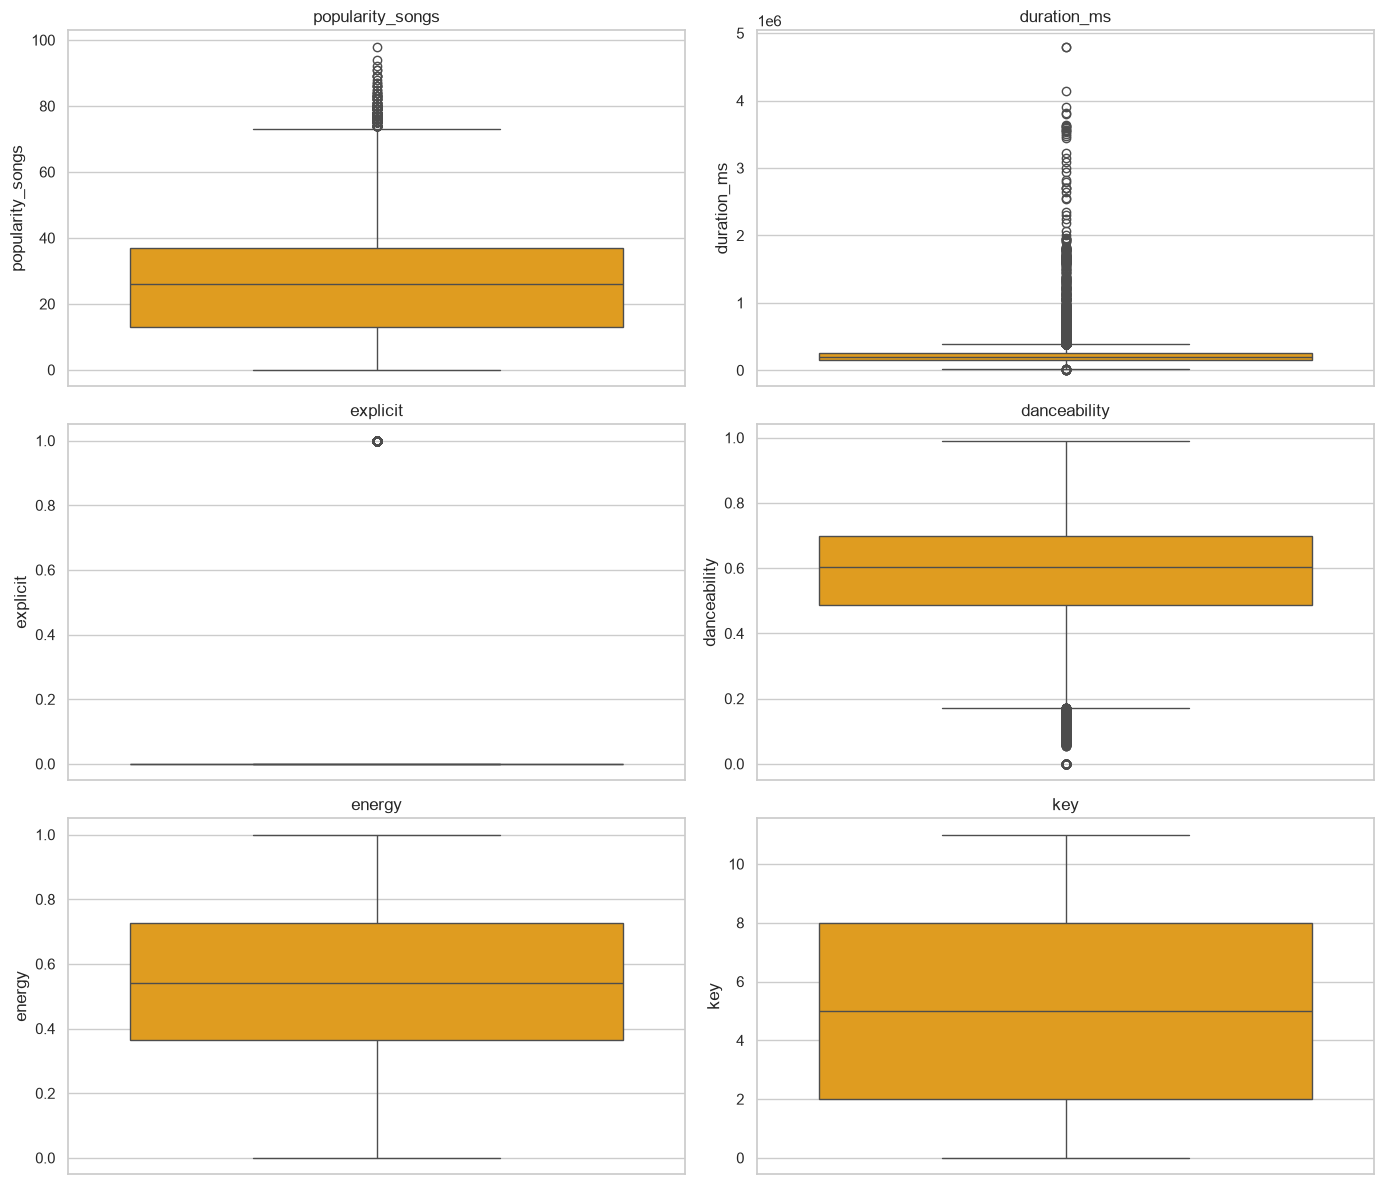

In [22]:
# Plot boxplots for numeric columns.
if len(plot_columns) == 0:
    print('No numeric columns found for boxplots.')
else:
    rows = int(np.ceil(len(plot_columns) / 2))
    fig, axes = plt.subplots(rows, 2, figsize=(14, 4 * rows))
    axes = np.array(axes).reshape(-1)
    for ax, column in zip(axes, plot_columns):
        sns.boxplot(y=df_clean[column], ax=ax, color='orange')
        ax.set_title(column)
    for ax in axes[len(plot_columns):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()


# Correlation Heatmap
Correlation shows how numeric columns move together.
This helps us understand which features are related.


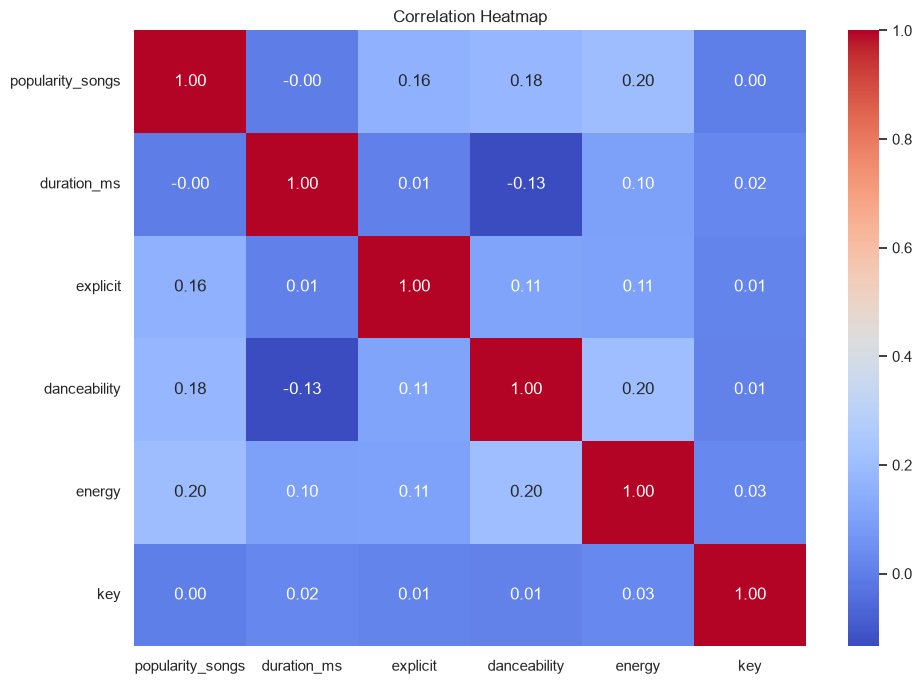

In [23]:
# Show the correlation heatmap.
if len(plot_columns) >= 2:
    corr_matrix = df_clean[plot_columns].corr()
    plt.figure(figsize=(10, 7))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Heatmap')
    plt.tight_layout()
    plt.show()
else:
    print('Not enough numeric columns for a correlation heatmap.')


# Feature Selection
We choose the columns we will use for clustering.
Usually numeric columns are the best choice for this project.


In [24]:
# Select features for clustering.
feature_data = df_clean.select_dtypes(include=np.number).copy()

if feature_data.shape[1] < 2:
    text_columns = df_clean.select_dtypes(exclude=np.number).columns.tolist()
    if len(text_columns) > 0:
        feature_data = pd.get_dummies(df_clean[text_columns], drop_first=True)

if feature_data.shape[1] < 2:
    raise ValueError('Not enough features for clustering.')

print('Selected feature shape:', feature_data.shape)
display(feature_data.head())


Selected feature shape: (95837, 17)


,popularity_songs,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,popularity_artists
0,0,161427,0,0.563,0.184,4,-13.757,1,0.0512,0.993,0.000016,0.325,0.654,133.088,3,5078.0,22
1,0,223440,0,0.427,0.180,10,-15.375,1,0.0670,0.989,0.000000,0.128,0.431,78.459,3,5078.0,22
2,0,208267,0,0.511,0.206,0,-15.514,1,0.0592,0.995,0.000000,0.418,0.481,70.443,4,5078.0,22
3,0,161933,0,0.676,0.467,9,-12.393,0,0.1650,0.991,0.000000,0.219,0.726,129.775,4,5078.0,22
4,0,167973,0,0.650,0.298,9,-13.806,1,0.1380,0.991,0.000000,0.373,0.844,75.950,4,5078.0,22


# StandardScaler
StandardScaler changes the data to a common scale.
This is important because clustering uses distances.


In [25]:
# Scale the feature values.
scaler = StandardScaler()
scaled_features = scaler.fit_transform(feature_data)
scaled_df = pd.DataFrame(scaled_features, columns=feature_data.columns)
print('Scaled data shape:', scaled_df.shape)


Scaled data shape: (95837, 17)


# Elbow Method
The elbow method helps us choose a good number of clusters.
We look for the point where inertia starts to slow down.


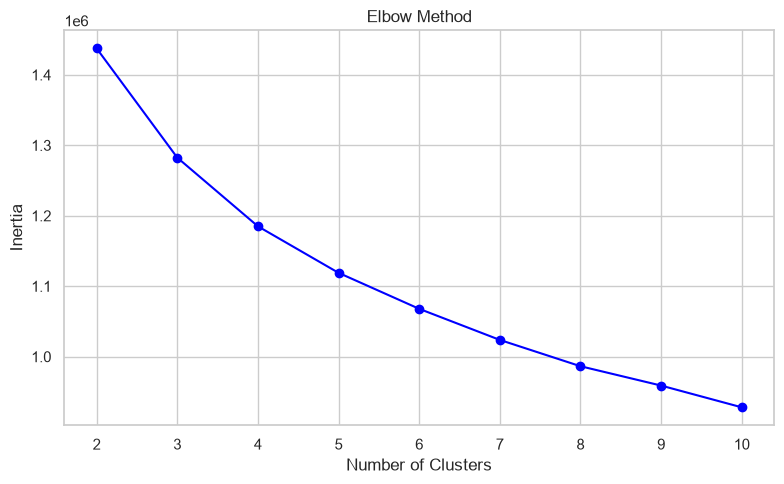

In [26]:
# Try different cluster numbers and store inertia.
k_values = range(2, min(10, len(scaled_df)) + 1)
inertia_values = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(scaled_df)
    inertia_values.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), inertia_values, marker='o', color='blue')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.tight_layout()
plt.show()


# Silhouette Score
Silhouette score tells us how well the clusters are separated.
Higher values usually mean better clusters.


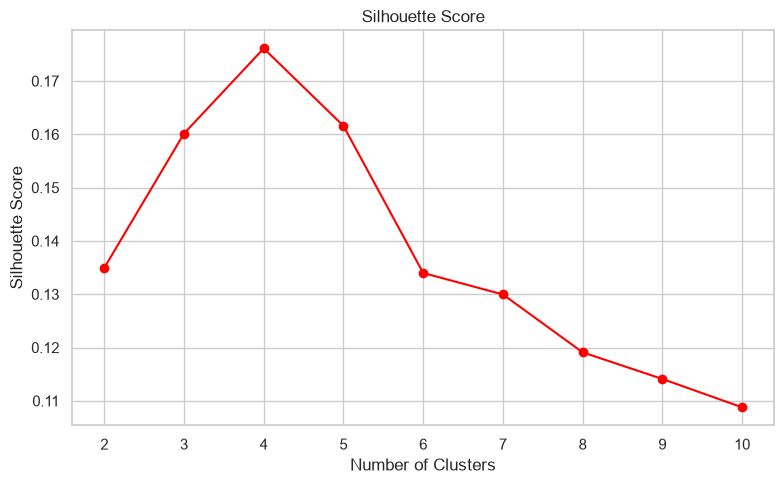

Best k: 4


In [28]:
# Check silhouette score for each k value.
silhouette_values = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(scaled_df)
    score = silhouette_score(scaled_df, labels) if len(set(labels)) > 1 else np.nan
    silhouette_values.append(score)

best_k = list(k_values)[int(np.nanargmax(silhouette_values))]

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), silhouette_values, marker='o', color='red')
plt.title('Silhouette Score')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

print('Best k:', best_k)


# K-Means Clustering
K-Means is the main clustering method in this notebook.
It groups records into a chosen number of clusters.


In [29]:
# Fit K-Means using the best k.
kmeans_model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans_model.fit_predict(scaled_df)
print('K-Means clustering completed')


K-Means clustering completed


# PCA Visualization
PCA reduces many features into 2 features for plotting.
This lets us see the clusters more clearly.


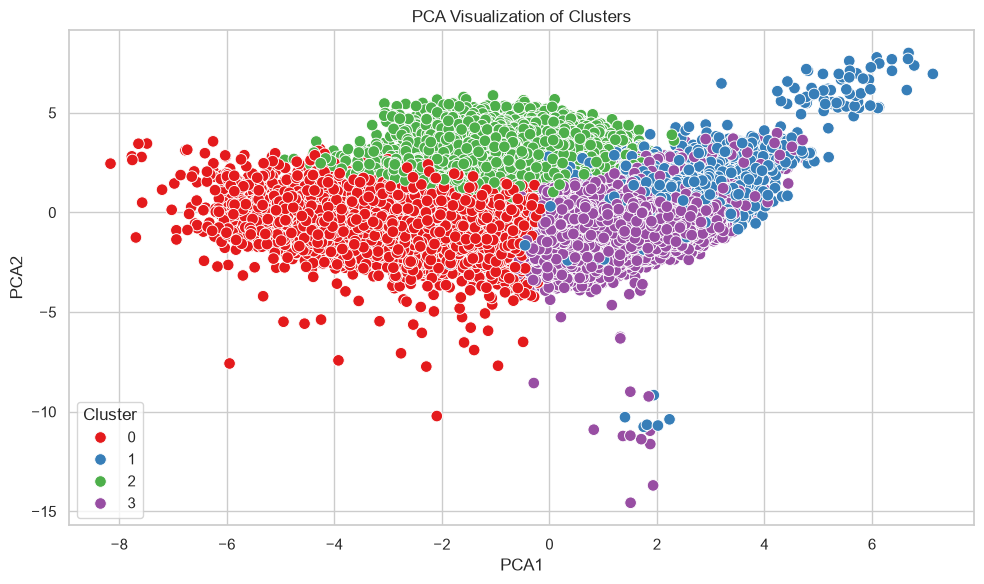

In [30]:
# Reduce the data to 2 dimensions with PCA.
pca = PCA(n_components=2, random_state=42)
pca_data = pca.fit_transform(scaled_df)
pca_df = pd.DataFrame(pca_data, columns=['PCA1', 'PCA2'])
pca_df['Cluster'] = kmeans_labels

plt.figure(figsize=(10, 6))
sns.scatterplot(data=pca_df, x='PCA1', y='PCA2', hue='Cluster', palette='Set1', s=70)
plt.title('PCA Visualization of Clusters')
plt.tight_layout()
plt.show()


# Cluster Analysis
We look at the average value of each feature in every cluster.
This helps us understand what makes the clusters different.


In [31]:
# Find the mean of each feature by cluster.
df_clustered = df_clean.copy()
df_clustered['KMeans_Cluster'] = kmeans_labels
cluster_summary = df_clustered.groupby('KMeans_Cluster').mean(numeric_only=True)
display(cluster_summary)


,popularity_songs,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,popularity_artists
KMeans_Cluster,,,,,,,,,,,,,,,,,
0,17.638357,219796.620828,0.000000,0.492218,0.311139,5.089392,-13.375881,0.688907,0.072789,0.759203,0.170935,0.188378,0.439737,112.067852,3.776682,95655.037193,32.335576
1,41.277701,211607.537853,0.977632,0.686893,0.684621,5.460083,-7.077630,0.540606,0.197389,0.245191,0.026626,0.201564,0.537117,118.442186,3.974880,928419.563661,52.756022
2,29.568678,89985.970788,0.000000,0.661731,0.478367,4.996233,-13.127801,0.650707,0.836445,0.566324,0.000619,0.434747,0.581001,100.342888,3.553193,243177.519545,74.045786
3,29.552912,230068.438818,0.000000,0.621626,0.689733,5.295682,-7.640447,0.628456,0.067176,0.260369,0.049985,0.198765,0.657930,124.970857,3.961469,208015.169623,41.265700


# DBSCAN
DBSCAN is another clustering method.
It groups dense points and can mark some points as noise.


In [32]:
# Run DBSCAN on the scaled data.
dbscan_model = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan_model.fit_predict(scaled_df)
df_clustered['DBSCAN_Cluster'] = dbscan_labels
print('DBSCAN labels:', sorted(set(dbscan_labels)))


DBSCAN labels: [np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37)]


# Hierarchical Clustering
Hierarchical clustering makes clusters step by step.
It is useful for comparing with K-Means and DBSCAN.


In [44]:
# Take a random sample for Hierarchical Clustering
sample_df = scaled_df.sample(n=10000, random_state=42)

# Fit Hierarchical Clustering
hierarchical_model = AgglomerativeClustering(n_clusters=best_k)
hierarchical_labels = hierarchical_model.fit_predict(sample_df)

# Add cluster labels to the sampled data
sample_df["Hierarchical_Cluster"] = hierarchical_labels

print("Hierarchical Clustering completed successfully!")

Hierarchical Clustering completed successfully!


# Evaluation Metrics
We check how good the clusters are using common metrics.
This gives a fair comparison between the algorithms.


In [45]:
# Compute evaluation scores.
kmeans_silhouette = silhouette_score(scaled_df, kmeans_labels) if len(set(kmeans_labels)) > 1 else np.nan
kmeans_dbi = davies_bouldin_score(scaled_df, kmeans_labels) if len(set(kmeans_labels)) > 1 else np.nan
kmeans_inertia = kmeans_model.inertia_

print('K-Means Silhouette:', round(kmeans_silhouette, 4))
print('K-Means Davies-Bouldin Index:', round(kmeans_dbi, 4))
print('K-Means Inertia:', round(kmeans_inertia, 4))


K-Means Silhouette: 0.1761
K-Means Davies-Bouldin Index: 1.7837
K-Means Inertia: 1184986.0122


# Business Insights
Clusters can help us group similar music records.
This can support recommendation systems and content analysis.


In [41]:
# Print simple business insights.
cluster_sizes = df_clustered['KMeans_Cluster'].value_counts().sort_index()
print('Cluster sizes:')
print(cluster_sizes)
print('The clusters can help identify groups of similar music records.')


Cluster sizes:
KMeans_Cluster
0    30920
1     2906
2    11947
3    50064
Name: count, dtype: int64
The clusters can help identify groups of similar music records.


# Conclusion
We completed a full beginner-friendly clustering project.
The data is cleaned, clustered, and ready for export.


In [42]:
# Final project message.
print('Amazon Music Clustering project completed successfully.')


Amazon Music Clustering project completed successfully.


# Export Final Dataset
We save the final dataset with cluster labels.
This file can be used for submission or future analysis.


In [43]:
# Export the final dataframe.
output_path = Path('Amazon_Music_Clustered.csv')
df_clustered.to_csv(output_path, index=False)
print('Saved to:', output_path.resolve())


Saved to: C:\vs project\guvi 4\Amazon_Music_Clustered.csv
